In [1]:
import sys
import os
# Add the parent directory to the Python path
sys.path.append(os.path.abspath('..'))
from simu_PSF_polarMFM_JAX import *
from simu_PSF_polarMFM import *
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import torch

print(jax.devices())

E0422 16:21:36.317696   19898 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0422 16:21:36.327664   19774 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


[CudaDevice(id=0)]


In [2]:
N_photons=jax.device_put(1000) # number of photons collected 
N=jax.device_put(80) # discretization of the BFP
l_pixel=jax.device_put(16) #pixel size in micrometer
NA=jax.device_put(1.4) # numerical aperture
mag=jax.device_put(100) # first magnification
lambd=jax.device_put(617) # wavelength
f_tube=jax.device_put(200) # tube lens focal
MAG=jax.device_put(200/150) # second magnification

In [3]:
J1 = jnp.array([[ 1.2604369        ,             -0.44922367 + 1j*  0.6776327 ],[
      -0.40610462 + 1j*  0.6554575  ,   -1.2775537 + 1j*  0.034650166 ]])
J2 = jnp.array([[ 0.57820666               ,      -1.2006966 + 1j*  0.67720294 ],[
      1.0710695 + 1j*  0.8422108   ,  0.2654659 + 1j*  0.58898413 ]])
J_dichroic = jnp.array([J1, J2, J1])

In [4]:
x, y, th1, phi, (Ex0, Ex1, Ex2), (Ey0, Ey1, Ey2), r, r_cut, k, f_o = vectorial_BFP_perfect_focus_jax(N, NA, mag, lambd, f_tube, J_dichroic=J_dichroic)

In [5]:
zernike_base = generate_zernike_base_jax(r_cut, N, zernike_order=4)

In [6]:
u, v, Npadding = padding_jax(r, r_cut, k, f_o)
print(Npadding)

74


In [7]:
xp = jnp.array([0.3,0.,0.,0.,0.])
yp = jnp.array([0.,0.,0.,0.,0.])
zp = jnp.array([3.*0.617,1.,1.,1.,1.])
d = -3.6*0.617/0.8+0.35
second_plane = jnp.array([0.3, 0, -0.3])
polar_projections = jnp.array([0., 45., 0.])

In [8]:
th1 = pad_jax(th1, Npadding)
phi = pad_jax(phi, Npadding)
Ex0 = pad_jax(Ex0, Npadding)
Ex1 = pad_jax(Ex1, Npadding)
Ex2 = pad_jax(Ex2, Npadding)
Ey0 = pad_jax(Ey0, Npadding)
Ey1 = pad_jax(Ey1, Npadding)
Ey2 = pad_jax(Ey2, Npadding)
zernike_base = pad_jax(zernike_base, Npadding)

In [9]:
zernike_base.shape

(15, 154, 154)

In [10]:
Mj = compute_M_jax(xp, yp, zp, d, x, y, th1, phi, Ex0, Ex1, Ex2, Ey0, Ey1, Ey2, u, v, zernike_base, jnp.zeros((3,15)), jnp.zeros((3,15)),  second_plane=second_plane
                  , polar_projections=polar_projections)

In [11]:
rho = jnp.array([45.,30.,40.,80.,100.])
eta = jnp.array([45.,60.,30.,80.,50.])
delta = jnp.array([50.,100.,100.,100.,100.])
N_photons = jnp.array([1000.,1000.,1000.,1000.,1000.])

In [12]:
psf_jax = PSF_jax(rho, eta, delta, Mj, N_photons)

(70.0, 85.0)

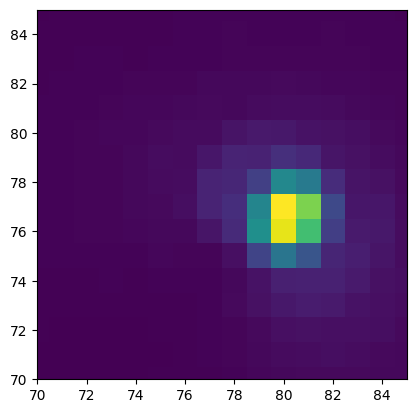

In [14]:
plt.imshow(psf_jax[0,0,0])
plt.xlim((70,85))
plt.ylim((70,85))

In [15]:
psf_jax.shape

(5, 3, 2, 154, 154)

In [16]:
Mj.shape

(5, 3, 2, 3, 3, 154, 154)

(62.0, 92.0)

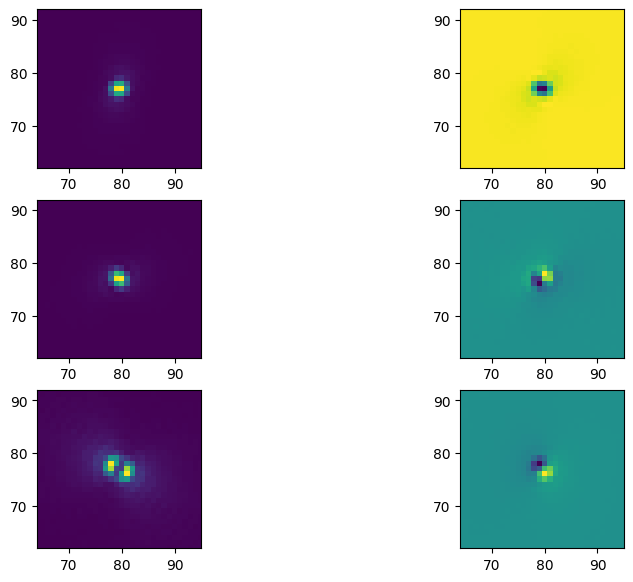

In [17]:
plt.rcParams['figure.figsize'] = [10,7]
fig, ax = plt.subplots(3,2)
ax[0,0].imshow(jnp.real(Mj[0,0,0,0,0]+Mj[0,0,0,0,0]))
ax[0,0].set_xlim((64,95))
ax[0,0].set_ylim((62,92))
ax[0,1].imshow(jnp.real(Mj[0,0,0,0,1]+Mj[0,0,0,1,0]))
ax[0,1].set_xlim((64,95))
ax[0,1].set_ylim((62,92))
ax[1,0].imshow(jnp.real(Mj[0,0,0,1,1]+Mj[0,0,0,1,1]))
ax[1,0].set_xlim((64,95))
ax[1,0].set_ylim((62,92))
ax[1,1].imshow(jnp.real(Mj[0,0,0,1,2]+Mj[0,0,0,2,1]))
ax[1,1].set_xlim((64,95))
ax[1,1].set_ylim((62,92))
ax[2,0].imshow(jnp.real(Mj[0,0,0,2,2]+Mj[0,0,0,2,2]))
ax[2,0].set_xlim((64,95))
ax[2,0].set_ylim((62,92))
ax[2,1].imshow(jnp.real(Mj[0,0,0,0,2]+Mj[0,0,0,2,0]))
ax[2,1].set_xlim((64,95))
ax[2,1].set_ylim((62,92))

In [18]:
key = jax.random.PRNGKey(0)

In [19]:
psf_noise_jax = noise_jax(key, psf_jax, QE=0.95, EM=200, b=5.0, sigma_b=0.1, sigma_r=1.0, bias=5.0)

(70.0, 85.0)

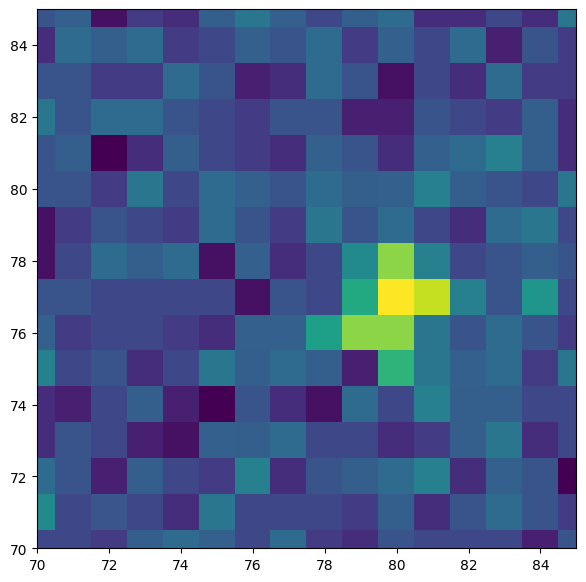

In [21]:
plt.imshow(psf_noise_jax[0,0,0])
plt.xlim((70,85))
plt.ylim((70,85))